In [1]:
# Compat shim for environments where matplotlib.rcParams lacks _get
import matplotlib as mpl
if not hasattr(mpl.rcParams, '_get'):
    mpl.rcParams._get = lambda key: mpl.rcParams.get(key)
print('rcParams._get shim applied (if needed)')

rcParams._get shim applied (if needed)


In [2]:
import pandas as pd
import numpy as np

# Read the cleaned file into a DataFrame
df = pd.read_csv('../data/bgg_rating_threshold.csv', sep=';', engine='c')

# Filter out rows with NaN user names before creating sparse matrix
df['bgg_user_name'] = df['bgg_user_name'].fillna('null')
df.head()

,bgg_id,bgg_user_name
0,50381.0,sumzor
1,68425.0,aquillo
2,105593.0,kenartyo
3,175199.0,mbialeck
4,95527.0,campanadave


In [3]:
from scipy.sparse import csr_matrix


user_codes = df["bgg_user_name"].astype("category").cat.codes
game_codes = df["bgg_id"].astype("category").cat.codes

n_users = user_codes.nunique()
n_games = game_codes.nunique()

R = csr_matrix(
    (np.ones(len(user_codes)), (user_codes, game_codes)),
    shape=(n_users, n_games)
)

popularity = np.array(R.sum(axis=0)).ravel()  # shape: (n_games,)
N = R.shape[0]  # number of users

In [4]:
co_likes = R.T @ R

## Rebuild Rust Module

If you've made changes to the Rust code, run these commands to recompile and install the module:

```bash
cd /workspaces/python-bgg/rust_bgg

# Build for the correct Python environment (Python 3.10 in conda env)
PYO3_PYTHON=/opt/conda/envs/bgg-gt/bin/python cargo build --release

# Remove old package directory if it exists (to avoid conflicts)
rm -rf /opt/conda/envs/bgg-gt/lib/python3.10/site-packages/rust_bgg
rm -rf /opt/conda/envs/bgg-gt/lib/python3.10/site-packages/rust_bgg-*.dist-info

# Copy the compiled library to the Python environment
cp target/release/librust_bgg.so /opt/conda/envs/bgg-gt/lib/python3.10/site-packages/rust_bgg.so

# Verify the module is available
/opt/conda/envs/bgg-gt/bin/python -c "import rust_bgg; print('Available functions:', dir(rust_bgg))"
```

After running these commands, restart the kernel to pick up the changes.

In [5]:
import numpy as np
import os
import sys
import scipy.sparse as sp

# Force reload of rust_bgg module to pick up new function
if 'rust_bgg' in sys.modules:
    del sys.modules['rust_bgg']

# Import rust_bgg
import rust_bgg

# Configuration
min_a = 10
llr_thresh = 20.0
out_path = '../data/bedges.csv'

os.makedirs(os.path.dirname(out_path), exist_ok=True)

# Convert sparse matrix data to numpy arrays for Rust without COO
if isinstance(co_likes, sp.csc_matrix):
    n_cols = co_likes.shape[1]
    rows_arr = co_likes.indices.astype(np.int32, copy=False)
    cols_arr = np.repeat(np.arange(n_cols, dtype=np.int32), np.diff(co_likes.indptr))
elif isinstance(co_likes, sp.csr_matrix):
    n_rows = co_likes.shape[0]
    rows_arr = np.repeat(np.arange(n_rows, dtype=np.int32), np.diff(co_likes.indptr))
    cols_arr = co_likes.indices.astype(np.int32, copy=False)
else:
    raise TypeError(f"Unsupported sparse format: {type(co_likes)}; expected CSC or CSR.")

data_arr = co_likes.data.astype(np.float64, copy=False)
pop_arr = popularity.astype(np.float64)

print(f"Processing {len(data_arr)} edges...")

# Call Rust function to process edges and write CSV directly
count = rust_bgg.process_edges_to_csv(
    rows_arr, cols_arr, data_arr, pop_arr, float(N), float(min_a), float(llr_thresh), out_path
)

print(f'Filtered to {count} valid edges and wrote to {out_path}')
# Processing 235841661 edges...
# Filtered to 42503010 valid edges and wrote to ../data/bedges.csv

Processing 673286719 edges...
Filtered to 50341626 valid edges and wrote to ../data/bedges.csv


In [6]:
import pandas as pd
from numba import njit
import numpy as np
# Read the edges data from the CSV file written by Rust
bedges = pd.read_csv('../data/bedges.csv', sep=';')
print(f"Loaded {len(bedges)} edges from CSV")

# Convert to numpy array for processing
bedges_arr = bedges[['game_i', 'game_j', 'a', 'cosine', 'jaccard']].values.astype(np.float64)

edges_i = bedges_arr[:, 0].astype(np.int32)
edges_j = bedges_arr[:, 1].astype(np.int32)
edges_w = bedges_arr[:, 4].astype(np.float64)  # jaccard
n_games = int(max(edges_i.max(), edges_j.max()) + 1)

@njit
def topk_per_node(edges_i, edges_j, edges_w, n_nodes, K):
    neigh = -np.ones((n_nodes, K), dtype=np.int32)
    weight = -np.inf * np.ones((n_nodes, K), dtype=np.float64)

    for k in range(len(edges_w)):
        i = edges_i[k]
        j = edges_j[k]
        w = edges_w[k]

        # i -> j
        m = 0
        min_w = weight[i, 0]
        for t in range(1, K):
            if weight[i, t] < min_w:
                min_w = weight[i, t]
                m = t
        if w > min_w:
            weight[i, m] = w
            neigh[i, m] = j

        # j -> i (undirected)
        m = 0
        min_w = weight[j, 0]
        for t in range(1, K):
            if weight[j, t] < min_w:
                min_w = weight[j, t]
                m = t
        if w > min_w:
            weight[j, m] = w
            neigh[j, m] = i

    return neigh, weight

neighbors, weights = topk_per_node(
    edges_i,
    edges_j,
    edges_w,
    n_games,
    K=10
)
final_neighbors = []

for gg in range(n_games):
    valid = neighbors[gg] != -1
    nbrs = neighbors[gg][valid]
    ws = weights[gg][valid]

    order = np.argsort(-ws)
    for n, w in zip(nbrs[order], ws[order]):
        final_neighbors.append((gg, n, w))


Loaded 50341626 edges from CSV


In [7]:
import igraph as ig
# Vectorized encoding of items/users → integer indices
item_codes, unique_items = pd.factorize(df['bgg_id'], sort=True)      # consistent sorted unique ids
# Fast, vectorized lookup (replaces the slow per-item loop)
df_game_item_from_bgg = pd.read_csv('../data/boardgames_ranks.csv')

# Build lookup once
id_to_name = df_game_item_from_bgg.set_index('id')['name']
# Build igraph from final_neighbors edge list
# final_neighbors is a list of (game, neighbor, lift_score) tuples representing top-50 neighbors per game

# Collect all unique nodes from the edge list
nodes_set = set()
for game, neighbor, lift_score in final_neighbors:
    nodes_set.add(game)
    nodes_set.add(neighbor)

nodes = sorted(nodes_set)  # Sort for consistency
name_to_idx = {name: idx for idx, name in enumerate(nodes)}

# Build edge list and weights, filtering out non-positive weights and duplicates
# Use a dict to track unique edges (keeping the max weight for duplicates)
edge_dict = {}
for game, neighbor, lift_score in final_neighbors:
    if lift_score is not None and lift_score > 0:  # Filter out negative and None weights
        # Normalize edge to avoid (u,v) and (v,u) duplicates for undirected graph
        u, v = name_to_idx[game], name_to_idx[neighbor]
        edge_key = (min(u, v), max(u, v))  # Canonical form
        
        # Keep the maximum weight if duplicate
        if edge_key not in edge_dict or lift_score > edge_dict[edge_key]:
            edge_dict[edge_key] = lift_score

# Convert dict to lists
sedges = list(edge_dict.keys())
weightr_vals = list(edge_dict.values())

# Create igraph graph (undirected since neighbor relationships are typically symmetric)
g = ig.Graph(n=len(nodes), edges=sedges, directed=False)

# Add BGG IDs
g.vs['id'] = [unique_items[node] for node in nodes]

# Add game names
bgg_ids = [unique_items[node] for node in nodes]
game_names = id_to_name.reindex(bgg_ids).values
game_names = np.where(pd.isna(game_names), [str(bgg_id) for bgg_id in bgg_ids], game_names)
g.vs['game_name'] = game_names.tolist()

g.es['weight'] = weightr_vals     # edge weight from lift_score

# Quick summary and sanity checks
print(g.summary())
print(f"Vertices: {len(nodes)}, Edges: {len(sedges)} (unique)")
print(f"Vertex attributes present: {sorted(g.vs.attributes())}")
print(f"Edge attributes present: {sorted(g.es.attributes())}")


IGRAPH U-W- 40634 328818 -- 
+ attr: game_name (v), id (v), weight (e)
Vertices: 40634, Edges: 328818 (unique)
Vertex attributes present: ['game_name', 'id']
Edge attributes present: ['weight']


In [8]:
# Check if the graph is fully connected
is_connected = g.is_connected()
print(f"Is graph fully connected? {is_connected}")

if not is_connected:
    # Get connected components
    components = g.connected_components()
    n_components = len(components)
    component_sizes = [len(comp) for comp in components]
    
    print(f"\nNumber of connected components: {n_components}")
    print(f"Largest component size: {max(component_sizes)}")
    print(f"Smallest component size: {min(component_sizes)}")
    print(f"Average component size: {np.mean(component_sizes):.2f}")
    
    # Show size distribution of components
    print(f"\nComponent size distribution:")
    unique_sizes, counts = np.unique(component_sizes, return_counts=True)
    for size, count in sorted(zip(unique_sizes, counts), reverse=True)[:10]:
        print(f"  {count} component(s) with {size} node(s)")
    
    # Show which games are isolated (if any)
    isolated_components = [comp for comp in components if len(comp) == 1]
    if isolated_components:
        print(f"\n{len(isolated_components)} isolated nodes (no significant connections):")
        for comp in isolated_components[:10]:  # Show first 10
            node_idx = comp[0]
            game_name = g.vs[node_idx]['game_name']
            game_id = g.vs[node_idx]['id']
            print(f"  - {game_name} (id={game_id})")
        if len(isolated_components) > 10:
            print(f"  ... and {len(isolated_components) - 10} more")
else:
    print("The graph is fully connected - all games are linked through significant similarities.")


Is graph fully connected? False

Number of connected components: 17
Largest component size: 40590
Smallest component size: 2
Average component size: 2390.24

Component size distribution:
  1 component(s) with 40590 node(s)
  1 component(s) with 6 node(s)
  2 component(s) with 4 node(s)
  4 component(s) with 3 node(s)
  9 component(s) with 2 node(s)


In [9]:
# Keep only the largest connected component in `g` and update dependent arrays
if not g.is_connected():
    comps = g.connected_components()
    largest = max(comps, key=len)
    print(f"Keeping largest component with {len(largest)} nodes (out of {g.vcount()})")
    # Induce subgraph on largest component (preserves vertex attributes)
    g = g.subgraph(largest)
else:
    print('Graph already connected; no pruning performed.')

Keeping largest component with 40590 nodes (out of 40634)


In [10]:
target_game_id = 383172

# Find the vertex index for this game id in the graph
target_vertex = None
for v in g.vs:
    if v['id'] == target_game_id:
        target_vertex = v
        break

if target_vertex is None:
    print(f"Game id {target_game_id} not found in graph.")
else:
    idx = target_vertex.index
    
    # Get neighbors from the graph
    neighbor_indices = g.neighbors(idx)
    
    if not neighbor_indices:
        print(f"No edges found for game id {target_game_id}")
    else:
        # Build a mapping from BGG ID to original matrix index
        # unique_items[matrix_idx] = bgg_id, so we need the reverse
        bgg_id_to_matrix_idx = {bgg_id: matrix_idx for matrix_idx, bgg_id in enumerate(unique_items)}
        
        # Get edge weights for each neighbor
        neighbors_data = []
        for nbr_idx in neighbor_indices:
            edge_id = g.get_eid(idx, nbr_idx)
            weight = g.es[edge_id]['weight']
            neighbors_data.append((nbr_idx, weight))
        
        # Sort by weight (descending)
        neighbors_data_sorted = sorted(neighbors_data, key=lambda x: x[1], reverse=True)
        
        top_n = min(100, len(neighbors_data_sorted))
        
        # Print results
        print(f"Top {top_n} neighbors for game id {target_game_id} ({target_vertex['game_name']}):")
        print("=" * 120)
        for rank, (nbr_idx, w) in enumerate(neighbors_data_sorted[:top_n], start=1):
            nbr_vertex = g.vs[nbr_idx]
            nbr_name = nbr_vertex['game_name']
            nbr_id = nbr_vertex['id']
            print(f"{rank:2d}. {nbr_name} (id={nbr_id}) | graph_weight={w:.4f}")
            
            # Convert graph vertex indices to original matrix indices using BGG IDs
            target_bgg_id = target_vertex['id']
            nbr_bgg_id = nbr_vertex['id']
            
            # Look up original matrix indices
            target_matrix_idx = bgg_id_to_matrix_idx.get(target_bgg_id)
            nbr_matrix_idx = bgg_id_to_matrix_idx.get(nbr_bgg_id)

            print()

Top 10 neighbors for game id 383172 (Nightshift):
 1. The Dick Sits (id=404455.0) | graph_weight=0.0870

 2. Foxpaw (id=385757.0) | graph_weight=0.0281

 3. Codenames: Back to Hogwarts (id=450782.0) | graph_weight=0.0247

 4. Puerto Rico 1897: Special Edition (id=415843.0) | graph_weight=0.0239

 5. Molly House (id=349750.0) | graph_weight=0.0237

 6. Brink (id=415078.0) | graph_weight=0.0217

 7. Artisans of Splendent Vale (id=342062.0) | graph_weight=0.0216

 8. Apothebakery: The Culinary Alchemists (id=411202.0) | graph_weight=0.0215

 9. Wonders of The First CCG (id=419763.0) | graph_weight=0.0209

10. Deep Regrets (id=397931.0) | graph_weight=0.0207



In [11]:
import leidenalg as la
partition = la.find_partition(g, la.ModularityVertexPartition, weights='weight',seed=42,  n_iterations=-1)

communities = partition.membership
print(partition.modularity)
print(partition.quality())

0.6645336677455049
0.8258204776134358


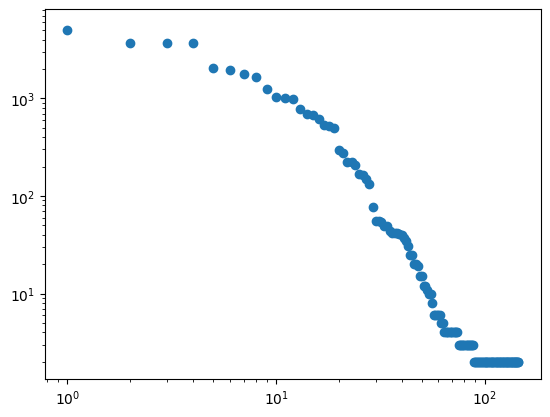

In [12]:
import matplotlib.pyplot as plt

unique_clusters, counts = np.unique(communities, return_counts=True)
cluster_counts = dict(zip(unique_clusters, counts))
plt.loglog(cluster_counts.keys(), cluster_counts.values(), 'o')

In [13]:

g.vs["community"] = communities

In [14]:
# Merge small communities (< 10 members) into larger ones based on graph connectivity
from collections import defaultdict
import numpy as np

MIN_COMMUNITY_SIZE = 10

# Get current community assignments (work on a copy)
communities_merged = np.array(communities.copy())

# Calculate community sizes
unique_comms, comm_sizes = np.unique(communities_merged, return_counts=True)
comm_size_dict = dict(zip(unique_comms, comm_sizes))

# Identify small and large communities
small_communities = [c for c, size in comm_size_dict.items() if size < MIN_COMMUNITY_SIZE]
large_communities = set([c for c, size in comm_size_dict.items() if size >= MIN_COMMUNITY_SIZE])

print(f"Communities before merging: {len(unique_comms)}")
print(f"Small communities (< {MIN_COMMUNITY_SIZE}): {len(small_communities)}")
print(f"Large communities (>= {MIN_COMMUNITY_SIZE}): {len(large_communities)}")

# For each small community, find which large community it has strongest connection to
merge_mapping = {}  # small_comm -> target_large_comm

for small_comm in small_communities:
    # Get all vertices in this small community
    vertices_in_small = [i for i, c in enumerate(communities_merged) if c == small_comm]
    
    # Calculate total weighted connections to each large community
    connections_to_large = defaultdict(float)
    
    for vertex_idx in vertices_in_small:
        # Get all neighbors of this vertex
        neighbors = g.neighbors(vertex_idx)
        
        for nbr_idx in neighbors:
            nbr_comm = communities_merged[nbr_idx]
            
            # Only consider connections to large communities
            if nbr_comm in large_communities:
                # Get edge weight
                edge_id = g.get_eid(vertex_idx, nbr_idx)
                weight = g.es[edge_id]['weight']
                connections_to_large[nbr_comm] += weight
    
    # Find the large community with strongest connection
    if connections_to_large:
        target_comm = max(connections_to_large.items(), key=lambda x: x[1])[0]
        merge_mapping[small_comm] = target_comm
        
        total_weight = sum(connections_to_large.values())
        print(f"  Community {small_comm} (size {comm_size_dict[small_comm]}) -> {target_comm} "
              f"(weight: {connections_to_large[target_comm]:.2f}/{total_weight:.2f})")
    else:
        print(f"  Warning: Community {small_comm} has no connections to large communities!")

# Apply the merging
for small_comm, target_comm in merge_mapping.items():
    communities_merged[communities_merged == small_comm] = target_comm

# Verify results
unique_comms_after, comm_sizes_after = np.unique(communities_merged, return_counts=True)
print(f"\nCommunities after merging: {len(unique_comms_after)}")
print(f"Smallest community size: {min(comm_sizes_after)}")
print(f"Largest community size: {max(comm_sizes_after)}")

# Update the graph with merged communities
g.vs["community"] = communities_merged.tolist()
communities = communities_merged.tolist()

print("\n✓ Communities merged and graph updated!")

Communities before merging: 146
Small communities (< 10): 90
Large communities (>= 10): 56
  Community 56 (size 8) -> 3 (weight: 0.10/0.23)
  Community 57 (size 6) -> 0 (weight: 0.02/0.02)
  Community 58 (size 6) -> 3 (weight: 0.12/0.28)
  Community 59 (size 6) -> 0 (weight: 0.13/0.23)
  Community 60 (size 6) -> 8 (weight: 0.01/0.01)
  Community 61 (size 6) -> 3 (weight: 0.15/0.31)
  Community 62 (size 5) -> 12 (weight: 0.02/0.02)
  Community 63 (size 5) -> 8 (weight: 0.15/0.15)
  Community 64 (size 4) -> 1 (weight: 0.01/0.03)
  Community 65 (size 4) -> 1 (weight: 0.01/0.02)
  Community 66 (size 4) -> 0 (weight: 0.04/0.06)
  Community 67 (size 4) -> 0 (weight: 0.02/0.02)
  Community 68 (size 4) -> 1 (weight: 0.00/0.00)
  Community 69 (size 4) -> 1 (weight: 0.00/0.00)
  Community 70 (size 4) -> 1 (weight: 0.00/0.00)
  Community 71 (size 4) -> 16 (weight: 0.23/0.27)
  Community 72 (size 4) -> 19 (weight: 0.06/0.07)
  Community 73 (size 4) -> 3 (weight: 0.13/0.16)
  Community 74 (size 4) 

In [15]:
# === Community attribute enrichment from bgg_GameItem(4).csv ===
import pandas as pd
import numpy as np
from collections import defaultdict

# 1) Build mapping: bgg_id -> community using graph 'g' vertex attribute
if 'g' in globals() and (hasattr(g, 'vs')) and ('community' in g.vs.attributes()):
    # Extract BGG IDs and communities from the graph (aligned by vertex order)
    bgg_ids_from_graph = pd.to_numeric(pd.Series([v['id'] for v in g.vs]), errors='coerce').astype('Int64')
    comm_from_graph = pd.Series(g.vs['community']).astype('Int64')

    id_comm = pd.DataFrame({
        'bgg_id': bgg_ids_from_graph,
        'community': comm_from_graph
    }).dropna()
else:
    raise RuntimeError("Missing 'g' or vertex attribute 'community'. Ensure earlier cells set g.vs['community'] before running.")

# 2) Load attributes file
attr_path = '../data/bgg_GameItem(4).csv'
df_attr = pd.read_csv(attr_path)
# Keep only ids that appear in the mapping
if 'bgg_id' not in df_attr.columns:
    raise RuntimeError("Expected column 'bgg_id' in bgg_GameItem(4).csv")

# Coerce to integer where possible
df_attr['bgg_id'] = pd.to_numeric(df_attr['bgg_id'], errors='coerce').astype('Int64')

# Merge community
df_attr = df_attr.merge(id_comm, on='bgg_id', how='inner')

# Identify columns by rough type
numeric_cols = [c for c in ['year','min_players_rec','max_players_rec','min_age_rec','min_time','max_time',
                            'rank','num_votes','bayes_rating','complexity'] if c in df_attr.columns]

# Columns that contain comma-separated categorical IDs
candidate_cat_cols = ['designer','artist','publisher','category','mechanic','family','implementation','integration',
                      'compilation','compilation_of']
cat_cols = [c for c in candidate_cat_cols if c in df_attr.columns]

# Explode categorical columns into long format (community, attr, token)
rows = []
for _, row_data in df_attr.iterrows():
    comm = row_data['community']
    for attr in cat_cols:
        val = row_data[attr]
        if pd.notna(val):
            tokens = str(val).split(',')
            for tok in tokens:
                tok_clean = tok.strip()
                if tok_clean:
                    rows.append((comm, attr, tok_clean))

cat_long = pd.DataFrame(rows, columns=['community', 'attr', 'token'])
print(f"Created cat_long with {len(cat_long)} token entries across {cat_long['community'].nunique()} communities")


/tmp/ipykernel_3217/1238024685.py:21: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attr = pd.read_csv(attr_path)


Created cat_long with 548983 token entries across 56 communities


In [16]:
# === Build single combined Top-3 attributes per community ===
import pandas as pd
import numpy as np
if 'df_attr' not in globals():
    raise RuntimeError("Attributes dataframe 'df_attr' not found. Run the enrichment cell first.")
# --- Human-readable mapping for attribute tokens from BGG CSVs ---
def _detect_col(cols, candidates):
    cl = [c.lower() for c in cols]
    for cand in candidates:
        if cand in cl:
            return cols[cl.index(cand)]
    for i, c in enumerate(cl):
        for cand in candidates:
            if cand in c:
                return cols[i]
    return None
def _load_map(path, id_cands, name_cands):
    try:
        dfm = pd.read_csv(path)
    except Exception:
        return {}
    if dfm is None or dfm.empty:
        return {}
    id_col = _detect_col(list(dfm.columns), [s.lower() for s in id_cands]) or _detect_col(list(dfm.columns), ['id'])
    name_col = _detect_col(list(dfm.columns), [s.lower() for s in name_cands]) or _detect_col(list(dfm.columns), ['name','value','label'])
    if id_col is None or name_col is None:
        return {}
    keys = pd.to_numeric(dfm[id_col], errors='coerce').dropna().astype(int)
    vals = dfm.loc[keys.index, name_col].astype(str)
    return dict(zip(keys.tolist(), vals.tolist()))
_base = '../data/'
publisher_map = _load_map(_base + 'bgg_Publisher.csv', id_cands=['publisher_id','id','link_id'], name_cands=['publisher','name','link_name','value'])
person_map    = _load_map(_base + 'bgg_Person.csv',    id_cands=['person_id','id','link_id'],    name_cands=['person','name','full_name','value'])
mechanic_map  = _load_map(_base + 'bgg_Mechanic.csv',  id_cands=['mechanic_id','id','link_id'],  name_cands=['mechanic','name','link_name','value'])
family_map    = _load_map(_base + 'bgg_GameFamily.csv',id_cands=['family_id','id','link_id'],    name_cands=['family','name','link_name','value'])
category_map  = _load_map(_base + 'bgg_Category.csv',  id_cands=['category_id','id','link_id'],  name_cands=['category','name','link_name','value'])
mapping_by_attr = {'publisher': publisher_map,'designer': person_map,'artist': person_map,'mechanic': mechanic_map,'family': family_map,'category': category_map}
def _map_token(attr, tok):
    if pd.isna(tok):
        return tok
    m = mapping_by_attr.get(attr)
    if not m:
        return tok
    key = None
    try:
        key = int(pd.to_numeric(tok))
    except Exception:
        pass
    if key is not None and key in m:
        return m[key]
    return m.get(str(tok), tok)
# 1) Add recommended players range tokens
players_cols_present = all(c in df_attr.columns for c in ['min_players_rec','max_players_rec'])
player_rows = []
if players_cols_present:
    for comm, minr, maxr in zip(df_attr['community'].values, df_attr['min_players_rec'].values, df_attr['max_players_rec'].values):
        if pd.isna(minr) or pd.isna(maxr):
            continue
        try:
            m = int(minr); M = int(maxr)
        except Exception:
            continue
        player_rows.append((comm, 'players_range', f"{m}-{M}"))
players_long = pd.DataFrame(player_rows, columns=['community','attr','token']) if player_rows else pd.DataFrame(columns=['community','attr','token'])
# 2) Combine categorical tokens (existing cat_long) with players_long
if 'cat_long' in globals() and not cat_long.empty:
    cat_all = pd.concat([cat_long, players_long], ignore_index=True)
else:
    cat_all = players_long.copy()
# Compute categorical salience per community
if not cat_all.empty:
    token_counts_all = cat_all.groupby(['attr','token']).size().rename('global_count').reset_index()
    comm_token_counts_all = cat_all.groupby(['community','attr','token']).size().rename('count').reset_index()
    comm_sizes = df_attr.groupby('community').size().rename('comm_size').reset_index()
    cat_tmp = comm_token_counts_all.merge(token_counts_all, on=['attr','token'], how='left').merge(comm_sizes, on='community', how='left')
    cat_tmp['comm_freq'] = cat_tmp['count'] / cat_tmp['comm_size'].clip(lower=1)
    cat_tmp['global_freq'] = cat_tmp['global_count'] / len(df_attr)
    cat_tmp['lift'] = (cat_tmp['comm_freq'] + 1e-9) / (cat_tmp['global_freq'] + 1e-9)
    cat_tmp['score'] = cat_tmp['lift'] * np.log1p(cat_tmp['count'])
    cat_tmp['pct_in_comm'] = (cat_tmp['count'] / cat_tmp['comm_size'].clip(lower=1)) * 100.0
    cat_tmp = cat_tmp[cat_tmp['count'] >= 3]
    cat_candidates = cat_tmp[['community','attr','token','score','pct_in_comm']].copy()
    if not cat_candidates.empty:
        cat_candidates['token'] = cat_candidates.apply(lambda r: _map_token(r['attr'], r['token']), axis=1)
else:
    cat_candidates = pd.DataFrame(columns=['community','attr','token','score','pct_in_comm'])
# 3) Numeric attributes with effect size and range
numeric_keep = [c for c in ['year','min_age_rec','rank','num_votes','bayes_rating','complexity'] if c in df_attr.columns]
num_candidates = []
if numeric_keep:
    num_df = df_attr[['community'] + numeric_keep].copy()
    global_stats = {}
    for col in numeric_keep:
        vals_g = pd.to_numeric(num_df[col], errors='coerce').dropna()
        global_stats[col] = (vals_g.mean(), vals_g.std(ddof=0))
    for comm, grp in num_df.groupby('community'):
        n_comm = len(grp)
        for col in numeric_keep:
            vals = pd.to_numeric(grp[col], errors='coerce').dropna()
            if vals.empty:
                continue
            mean_g, std_g = global_stats[col]
            if std_g == 0 or np.isnan(std_g):
                continue
            mean_c = vals.mean()
            d = (mean_c - mean_g) / std_g
            q1, q3 = np.percentile(vals, [25, 75])
            pct = float((np.sum((vals >= q1) & (vals <= q3)) / len(vals)) * 100.0)
            value = f"{int(round(q1))}-{int(round(q3))}" if np.isfinite(q1) and np.isfinite(q3) else f"{mean_c:.2f}"
            score = float(abs(d) * np.log1p(n_comm))
            num_candidates.append({'community': int(comm), 'attr': col, 'value': value, 'score': score, 'direction': float(np.sign(d)), 'pct_in_comm': pct})
num_candidates_df = pd.DataFrame(num_candidates)
# 4) Merge categorical and numeric for unified top-3
if not cat_candidates.empty:
    cat_candidates = cat_candidates.rename(columns={'token': 'value'})
    cat_candidates['type'] = 'categorical'
else:
    cat_candidates = pd.DataFrame(columns=['community','attr','value','score','pct_in_comm','type'])
if not num_candidates_df.empty:
    num_candidates_df['type'] = 'numeric'
else:
    num_candidates_df = pd.DataFrame(columns=['community','attr','value','score','pct_in_comm','direction','type'])
combined = pd.concat([cat_candidates[['community','attr','value','score','pct_in_comm','type']], num_candidates_df[['community','attr','value','score','pct_in_comm','type']]], ignore_index=True)
# Apply minimum coverage threshold before ranking
PCT_MIN = 30.0
if not combined.empty and 'pct_in_comm' in combined.columns:
    combined = combined[combined['pct_in_comm'] >= PCT_MIN]
# Pick attributes per community: all 100% coverage, then fill to 3 with next highest
def top3_per_comm(df_comb):
    out = []
    for comm, grp in df_comb.groupby('community'):
        if grp.empty:
            continue
        # Sort by pct_in_comm descending
        sorted_grp = grp.sort_values('pct_in_comm', ascending=False)
        # Get all 100% coverage attributes
        perfect = sorted_grp[sorted_grp['pct_in_comm'] >= 99.99]
        # Get remaining to fill up to 3 total (if needed)
        remaining = sorted_grp[sorted_grp['pct_in_comm'] < 99.99]
        n_perfect = len(perfect)
        if n_perfect >= 3:
            # If we have 3+ perfect matches, show all of them
            top = perfect
        else:
            # Show all perfect + fill up to 3 with next highest
            top = pd.concat([perfect, remaining.head(3 - n_perfect)])
        out.append(top)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=['community','attr','value','score','pct_in_comm','type'])
combined_top3 = top3_per_comm(combined)

# Also compute top 3 by lift score for comparison
def top3_by_lift(df_comb):
    out = []
    for comm, grp in df_comb.groupby('community'):
        if grp.empty:
            continue
        top = grp.sort_values('score', ascending=False).head(3)
        out.append(top)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=['community','attr','value','score','pct_in_comm','type'])
combined_top3_lift = top3_by_lift(combined)
# 5) Attach an example game per community
example_games = []
if 'id_to_name' not in globals():
    try:
        df_game_item_from_bgg
    except NameError:
        try:
            df_game_item_from_bgg = pd.read_csv('../data/boardgames_ranks.csv')
        except Exception:
            df_game_item_from_bgg = None
for comm, grp in df_attr.groupby('community'):
    cand = grp.copy()
    if 'num_votes' in cand.columns and cand['num_votes'].notna().any():
        cand = cand.sort_values(by='num_votes', key=lambda s: pd.to_numeric(s, errors='coerce'), ascending=False)
    elif 'bayes_rating' in cand.columns and cand['bayes_rating'].notna().any():
        cand = cand.sort_values(by='bayes_rating', key=lambda s: pd.to_numeric(s, errors='coerce'), ascending=False)
    bgg_ids = pd.to_numeric(cand['bgg_id'], errors='coerce').dropna()
    if bgg_ids.empty:
        continue
    bgg_id_sample = int(bgg_ids.iloc[0])
    name_val = None
    try:
        if 'id_to_name' in globals() and id_to_name is not None:
            name_val = id_to_name.get(bgg_id_sample, None)
        if (name_val is None) and (df_game_item_from_bgg is not None):
            ser = df_game_item_from_bgg[df_game_item_from_bgg['id'] == bgg_id_sample]['name']
            if not ser.empty:
                name_val = ser.iloc[0]
    except Exception:
        name_val = None
    if name_val is None:
        name_val = str(bgg_id_sample)
    example_games.append({'community': int(comm), 'example_game': str(name_val)})
example_df = pd.DataFrame(example_games)
if not example_df.empty and not combined_top3.empty:
    combined_top3 = combined_top3.merge(example_df, on='community', how='left')
# Display original table
# print("\nSingle combined Top-3 attributes per community (normalized within community):")
# if not combined_top3.empty:
#     display(combined_top3[['community','attr','value','type','score','score_norm','pct_in_comm','example_game']])
# else:
#     print("No attributes found to summarize.")
# Aggregated view by community: list values with integer pct, drop attr/score_norm/type
if not combined_top3.empty:
    agg_df = combined_top3.copy()
    cols_to_drop = [c for c in ['attr','score_norm','type'] if c in agg_df.columns]
    if cols_to_drop:
        agg_df = agg_df.drop(columns=cols_to_drop)
    if 'pct_in_comm' in agg_df.columns:
        agg_df['pct_in_comm'] = agg_df['pct_in_comm'].round().astype('Int64')
    # Build "value (pct%)" strings
    if 'pct_in_comm' in agg_df.columns:
        agg_df['value_pct'] = agg_df.apply(lambda r: f"{r['value']} ({int(r['pct_in_comm'])}%)", axis=1)
    else:
        agg_df['value_pct'] = agg_df['value'].astype(str)
    # Keep one example_game per community if present
    example_per_comm = agg_df[['community','example_game']].drop_duplicates() if 'example_game' in agg_df.columns else None
    grouped = agg_df.groupby('community', as_index=False).agg({'value_pct': lambda s: ', '.join(map(str, s))})
    grouped = grouped.rename(columns={'value_pct': 'top_by_coverage'})
    if example_per_comm is not None:
        grouped = grouped.merge(example_per_comm, on='community', how='left')
    
    # Add lift-based top 3
    if not combined_top3_lift.empty:
        agg_df_lift = combined_top3_lift.copy()
        cols_to_drop_lift = [c for c in ['attr','score_norm','type'] if c in agg_df_lift.columns]
        if cols_to_drop_lift:
            agg_df_lift = agg_df_lift.drop(columns=cols_to_drop_lift)
        if 'pct_in_comm' in agg_df_lift.columns:
            agg_df_lift['pct_in_comm'] = agg_df_lift['pct_in_comm'].round().astype('Int64')
        if 'pct_in_comm' in agg_df_lift.columns:
            agg_df_lift['value_pct'] = agg_df_lift.apply(lambda r: f"{r['value']} ({int(r['pct_in_comm'])}%)", axis=1)
        else:
            agg_df_lift['value_pct'] = agg_df_lift['value'].astype(str)
        grouped_lift = agg_df_lift.groupby('community', as_index=False).agg({'value_pct': lambda s: ', '.join(map(str, s))})
        grouped_lift = grouped_lift.rename(columns={'value_pct': 'top_by_lift'})
        grouped = grouped.merge(grouped_lift, on='community', how='left')
    
    # Reorder columns
    display_cols = ['community','example_game','top_by_coverage','top_by_lift'] if 'example_game' in grouped.columns else ['community','top_by_coverage','top_by_lift']
    print("\nAggregated attributes by community:")
    display(grouped[display_cols])


Aggregated attributes by community:


,community,example_game,top_by_coverage,top_by_lift
0,0,Heat: Pedal to the Metal,"2019-2023 (61%), 8-12 (57%), 36-722 (51%)","Crowdfunding: Kickstarter (33%), Card Game (36..."
1,1,CATAN,"1-2 (76%), 8-12 (57%), 2008-2018 (52%)","6-7 (50%), Card Game (35%), 537-20678 (50%)"
2,2,Chess,"1-2 (76%), 6-10 (57%), 1986-2008 (53%)","(Uncredited) (45%), Roll / Spin and Move (31%)..."
3,3,Russian Railroads,"2011-2016 (65%), 8-12 (59%), 1-2 (50%)","Hand Management (31%), Card Game (38%), 4411-1..."
4,4,The Magic Labyrinth,"1-2 (76%), 5-10 (57%), 2011-2020 (56%)","2-4 (33%), Card Game (31%), 5-10 (57%)"
5,5,The Really Nasty Horse Racing Game,"1-2 (55%), 8-10 (52%), 1990-2005 (51%)","Card Game (30%), 14642-24900 (50%), 5-6 (50%)"
6,6,Kahuna,"1997-2006 (54%), 21-789 (51%), 8-10 (51%)","Card Game (31%), 8-10 (51%), 1-2 (50%)"
7,7,Commands & Colors: Ancients,"Wargame (92%), Dice Rolling (67%), 13-16 (52%)","World War II (36%), Wargame (92%), Simulation ..."
8,8,Under Falling Skies,"10-12 (55%), 2017-2022 (54%), 2-3 (51%)","Print & Play (33%), Solo / Solitaire Game (41%..."
9,9,Napoleon's Last Battles,"Wargame (99%), Hexagon Grid (86%), 16-16 (74%)",Players: Wargames with Rules Supporting Only T...


In [17]:
import os
from igraph import write

# Ensure graph g exists
try:
    g
except NameError:
    raise RuntimeError("Graph 'g' is not defined. Build it before exporting.")


os.makedirs("../graph", exist_ok=True)
output_path = "../graph/boardgames_graph_full.graphml"

# When exporting to DOT, igraph will include vertex attributes like 'pos'
write(g, output_path)
print(f"Written DOT file with positions: {output_path} ({g.vcount()} nodes, {g.ecount()} edges)")

Written DOT file with positions: ../graph/boardgames_graph_full.graphml (40590 nodes, 328774 edges)
